# 🏨 🏬 Modélisation de l'algorithme de prédiction de la consommation d'énergie des batâments non résidentiels de la ville de Seattle

### 📃 Context du document

La ville de seattle a un objectif de neutralité carbone d'ici 2050. 
En 2016, elle a effectué un relevé de tous les batâments de ville afin de connaitre leur consommation ainsi que leur émission de CO2. 

La ville souhaiterait actualiser ces données, mais ce genre de relevé est très couteux. 
C'est pourquoi nous souhaitons développer un modèle prédictif qui permettra de prédire la consommation d'énergie. 

Nous avons au préalable effectué une analyse exploratoire qui nous a permis de mieux appréhender les données. 
A présent, nous allons passer à la deuxième étape, qui consiste à préparer les données pour l'entrainement du modèle.

### 📒 Import des modules

In [124]:
# Manipulation
import pandas as pd
import numpy as np

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, IsolationForest

In [107]:
pd.options.display.float_format = '{:.2f}'.format

### 🔍 Lecture et filtrage du dataset

In [108]:
df = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

residential_building = ['Mixed Use Property',
                        'Residence Hall',
                        'High-Rise Multifamily',
                        'Low-Rise Multifamily',
                        'Other',
                        'Office',
                        'Mid-Rise Multifamily']

df = df[~df["PrimaryPropertyType"].isin(residential_building)]

### ⚙️ Features Engineering

In [109]:
col_to_keep = ['PrimaryPropertyType','YearBuilt', 'NumberofBuildings',
               'NumberofFloors', 'PropertyGFAParking','PropertyGFATotal', 
               'SiteEnergyUseWN(kBtu)']

df = df.loc[:,col_to_keep]

In [110]:
df.isna().sum()

PrimaryPropertyType      0
YearBuilt                0
NumberofBuildings        1
NumberofFloors           0
PropertyGFAParking       0
PropertyGFATotal         0
SiteEnergyUseWN(kBtu)    2
dtype: int64

In [111]:
df.describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFATotal,SiteEnergyUseWN(kBtu)
count,1305.00,1304.00,1305.00,1305.00,1305.00,1303.00
mean,1962.58,1.16,4.49,12902.58,124861.22,7555314.06
std,31.89,3.22,7.17,41971.25,322798.20,18660344.22
min,1900.00,0.00,0.00,0.00,16300.00,0.00
25%,1937.00,1.00,1.00,0.00,31357.00,1265929.25
50%,1966.00,1.00,3.00,0.00,52110.00,2626698.25
75%,1988.00,1.00,4.00,0.00,112896.00,6997391.50
max,2015.00,111.00,99.00,512608.00,9320156.00,296671744.00


In [112]:
# Remplacement des valeurs nulles de la variable énergie (médiane de la catégorie du bâtiment)
df['SiteEnergyUseWN(kBtu)'] = df['SiteEnergyUseWN(kBtu)'].replace(0, np.nan)
df['SiteEnergyUseWN(kBtu)'] = df['SiteEnergyUseWN(kBtu)'].fillna(
    df.groupby('PrimaryPropertyType')['SiteEnergyUseWN(kBtu)'].transform('median')
)

# Remplacement de la valeur nulle de la variable nombre de batiment (par défaut Nb bat = 1)
df['NumberofBuildings'] = df['NumberofBuildings'].fillna(1)

# Retraitement des NB bat = 0 par Nb bat = 1
df.loc[df['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1

# Retraitement des Nb floor, on considère que le RDC est le 1er étage
df['NumberofFloors'] += 1

In [113]:
# Année du bâtiment
df['Building_Age'] = 2016 - df['YearBuilt']

# Surface moyenne par étage
df['Mean_Surface_Per_Floor'] = round(df['PropertyGFATotal'] / df['NumberofFloors'],2)

# Ratio parking Surface totale
df['Parking_Ratio'] = round(df['PropertyGFAParking'] / df['PropertyGFATotal'],2) * 100

# One-Hot Encoding
df = pd.get_dummies(df, columns=['PrimaryPropertyType'], prefix='Type')

In [114]:
df_preprocess = df.copy()
df_preprocess = df_preprocess.loc[:,['PropertyGFATotal', 'SiteEnergyUseWN(kBtu)',
       'Building_Age', 'Mean_Surface_Per_Floor', 'Parking_Ratio',
       'Type_Distribution Center', 'Type_Hospital', 'Type_Hotel',
       'Type_K-12 School', 'Type_Laboratory', 'Type_Large Office',
       'Type_Medical Office', 'Type_Refrigerated Warehouse', 'Type_Restaurant',
       'Type_Retail Store', 'Type_Self-Storage Facility',
       'Type_Senior Care Community', 'Type_Small- and Mid-Sized Office',
       'Type_Supermarket / Grocery Store', 'Type_University', 'Type_Warehouse',
       'Type_Worship Facility']]

# 🤖 Modélisation

### Pipeline N°1️⃣ : Entrainement SANS log(y) et AVEC outliers

In [115]:
X = df_preprocess.drop('SiteEnergyUseWN(kBtu)', axis=1)
y = df_preprocess['SiteEnergyUseWN(kBtu)']

# X = les features, y = la target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)


lr = LinearRegression()
lr.fit(X_train, y_train)


svr = SVR(kernel='rbf') 
svr.fit(X_train, y_train)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

models = [dummy, lr, svr, rf]

results = []

for model in models:
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Stockage dans une liste de dictionnaires
    results.append({
        'Model': model.__class__.__name__,
        'R2': round(r2, 3),
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3)
    })

# Création du DataFrame de comparaison
df_perf = pd.DataFrame(results).sort_values(by='R2', ascending=False)
df_perf

,Model,R2,MAE,RMSE
3,RandomForestRegressor,0.43,3484405.63,9925444.18
0,DummyRegressor,-0.00,7739605.03,13183845.87
1,LinearRegression,-0.02,4185446.65,13303231.55
2,SVR,-0.14,6141470.39,14071500.62


### Pipeline N°2️⃣ : Entrainement AVEC log(y) et AVEC outliers

In [116]:
X = df_preprocess.drop('SiteEnergyUseWN(kBtu)', axis=1)
y = np.log1p(df_preprocess['SiteEnergyUseWN(kBtu)'])

# X = les features, y = la target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)


lr = LinearRegression()
lr.fit(X_train, y_train)


svr = SVR(kernel='rbf') 
svr.fit(X_train, y_train)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


models = [dummy, lr, svr, rf]

results = []

for model in models:
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Stockage dans une liste de dictionnaires
    results.append({
        'Model': model.__class__.__name__,
        'R2': round(r2, 3),
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3)
    })

# Création du DataFrame de comparaison
df_perf = pd.DataFrame(results).sort_values(by='R2', ascending=False)
df_perf

,Model,R2,MAE,RMSE
3,RandomForestRegressor,0.76,0.43,0.62
2,SVR,0.64,0.54,0.76
1,LinearRegression,0.62,0.57,0.78
0,DummyRegressor,-0.00,0.99,1.26


### Pipeline N°3️⃣ : Entrainement AVEC log(y) et SANS outliers

##### Méthode IQR

In [117]:
def remove_outliers_iqr(df, column_name):
    """
    Filtre les outliers d'un DataFrame en se basant sur la méthode IQR.
    """
    # Calcul du 1er quartile (Q1) et du 3ème quartile (Q3)
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    
    # Calcul de l'écart interquartile
    IQR = Q3 - Q1
    
    # Définition des bornes
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Séparation des données
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    df_clean = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    
    print(f"--- Méthode IQR sur {column_name} ---")
    print(f"Nombre d'outliers détectés : {len(outliers)}")
    print(f"Données conservées : {len(df_clean)}\n")
    
    return df_clean, outliers

# Exemple d'utilisation sur la variable cible
df_clean_iqr, df_outliers_iqr = remove_outliers_iqr(df, 'SiteEnergyUseWN(kBtu)')

--- Méthode IQR sur SiteEnergyUseWN(kBtu) ---
Nombre d'outliers détectés : 139
Données conservées : 1166



In [118]:
X = df_clean_iqr.drop('SiteEnergyUseWN(kBtu)', axis=1)
y = np.log1p(df_clean_iqr['SiteEnergyUseWN(kBtu)'])

# X = les features, y = la target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)


lr = LinearRegression()
lr.fit(X_train, y_train)


svr = SVR(kernel='rbf') 
svr.fit(X_train, y_train)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


models = [dummy, lr, svr, rf]

results = []

for model in models:
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Stockage dans une liste de dictionnaires
    results.append({
        'Model': model.__class__.__name__,
        'R2': round(r2, 3),
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3)
    })

# Création du DataFrame de comparaison
df_perf = pd.DataFrame(results).sort_values(by='R2', ascending=False)
df_perf

,Model,R2,MAE,RMSE
3,RandomForestRegressor,0.56,0.54,0.75
1,LinearRegression,0.50,0.58,0.80
2,SVR,0.40,0.61,0.88
0,DummyRegressor,-0.00,0.89,1.13


##### Méthode Isolation Forest

In [119]:
def remove_outliers_isolation_forest(df, columns_to_check, contamination=0.05):
    """
    Filtre les outliers en utilisant l'Isolation Forest (approche multivariée).
    contamination : le pourcentage estimé d'outliers dans le jeu de données.
    """
    # Copie pour éviter de modifier le dataframe original
    df_temp = df_preprocess.copy()
    
    # Suppression temporaire des NaN pour que l'algo puisse tourner
    df_temp = df_temp.dropna(subset=columns_to_check)
    
    # Initialisation du modèle
    # random_state assure la reproductibilité des résultats
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    
    # Entraînement et prédiction (retourne 1 pour inlier, -1 pour outlier)
    preds = iso_forest.fit_predict(df_temp[columns_to_check])
    
    # Ajout des prédictions au dataframe
    df_temp['anomaly_score'] = preds
    
    # Séparation des données
    outliers = df_temp[df_temp['anomaly_score'] == -1]
    df_clean = df_temp[df_temp['anomaly_score'] == 1].drop(columns=['anomaly_score'])
    
    print(f"--- Méthode Isolation Forest sur {columns_to_check} ---")
    print(f"Nombre d'outliers détectés (Contamination {contamination*100}%) : {len(outliers)}")
    print(f"Données conservées : {len(df_clean)}\n")
    
    return df_clean, outliers


variables_a_analyser = ['SiteEnergyUseWN(kBtu)', 'PropertyGFATotal']
df_clean_iso, df_outliers_iso = remove_outliers_isolation_forest(df, variables_a_analyser, contamination=0.03)

--- Méthode Isolation Forest sur ['SiteEnergyUseWN(kBtu)', 'PropertyGFATotal'] ---
Nombre d'outliers détectés (Contamination 3.0%) : 40
Données conservées : 1265



/Users/nassim/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [120]:
X = df_clean_iso.drop('SiteEnergyUseWN(kBtu)', axis=1)
y = np.log1p(df_clean_iso['SiteEnergyUseWN(kBtu)'])

# X = les features, y = la target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)


lr = LinearRegression()
lr.fit(X_train, y_train)


svr = SVR(kernel='rbf') 
svr.fit(X_train, y_train)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


models = [dummy, lr, svr, rf]

results = []

for model in models:
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Stockage dans une liste de dictionnaires
    results.append({
        'Model': model.__class__.__name__,
        'R2': round(r2, 3),
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3)
    })

# Création du DataFrame de comparaison
df_perf = pd.DataFrame(results).sort_values(by='R2', ascending=False)
df_perf

,Model,R2,MAE,RMSE
3,RandomForestRegressor,0.70,0.45,0.65
1,LinearRegression,0.64,0.52,0.71
2,SVR,0.54,0.57,0.81
0,DummyRegressor,-0.00,0.96,1.19


# 🧮 Ajustement des paramètres 

In [122]:
# 1. Préparation 
X = df_preprocess.drop('SiteEnergyUseWN(kBtu)', axis=1)
y = np.log1p(df_preprocess['SiteEnergyUseWN(kBtu)'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Définition de la grille de paramètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] # None utilise toutes les colonnes
}

# 3. Initialisation du modèle
rf = RandomForestRegressor(random_state=42)

# 4. Configuration de la recherche (CV=5 signifie 5 rotations de validation)
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='r2', 
                           n_jobs=-1, # Utilise tous les processeurs
                           verbose=2)

# 5. Entraînement
grid_search.fit(X_train, y_train)

# 6. Résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Évaluation sur le test set
y_pred_log = best_model.predict(X_test)
print(f"R2 Final (sur Log): {r2_score(y_test, y_pred_log):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Meilleurs paramètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
R2 Final (sur Log): 0.7632


Erreur Moyenne Absolue (MAE) : 2892849.16 kBtu


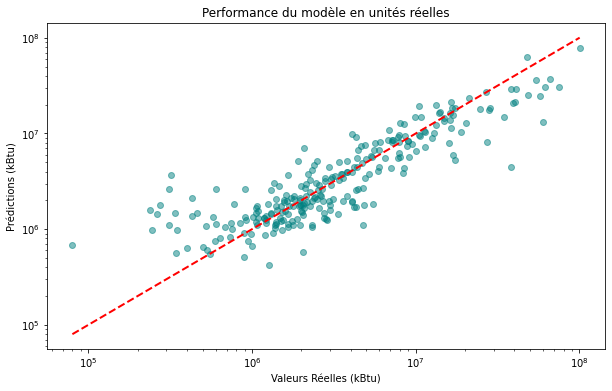

[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=   1.0s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=None, max_features=log2, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=

[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=   1.0s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, max_features=log2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, max_features=log2, min_samples_split=5, n_estimators=300; total time=   0.8s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=30

[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=None, max_features=log2, min_samples_split=5, n_estimators=2

[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   0.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=log2, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=None, max_features=log2, min_samples_split=5, n_estimators=300; total time=   0.7s
[CV] END max_depth=None, max_features=log2, min_samples_split=10, n_estimators=300; total time=   0.5s
[CV] END max_depth=None, max_features=None, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=None, min_samples_split=2, n_estimators=30

In [125]:
# 1. Inversion de la transformation log1p pour les prédictions et les vraies valeurs
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# 2. Calcul de la MAE réelle (en kBtu)
mae_real = mean_absolute_error(y_test_real, y_pred_real)

print(f"Erreur Moyenne Absolue (MAE) : {mae_real:.2f} kBtu")

# 3. Visualisation Prédictions vs Réalité
plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='teal')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles (kBtu)')
plt.ylabel('Prédictions (kBtu)')
plt.title('Performance du modèle en unités réelles')
plt.xscale('log') 
plt.yscale('log')
plt.show()

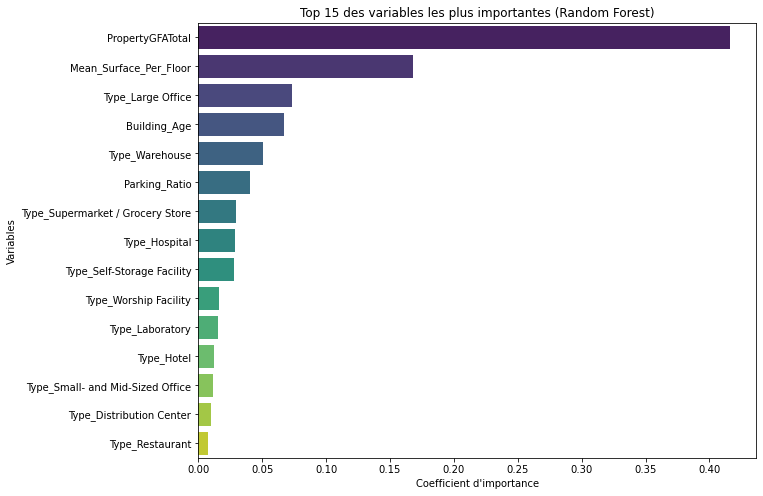

In [126]:
# Récupération des importances
importances = best_model.feature_importances_
feature_names = X.columns # Assure-toi que X contient tes noms de colonnes
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Affichage
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 des variables les plus importantes (Random Forest)')
plt.xlabel('Coefficient d\'importance')
plt.ylabel('Variables')
plt.show()